# Model Training and Evaluation 

With our data successfully prepared and split, we now move into the core modeling phase. Our objective is to build a classifier that can accurately distinguish between "ham" and "spam" messages.

In this notebook, we will develop a structured training pipeline to:
1.  **Vectorize the Text:** Convert our cleaned messages into numerical features using techniques like TF-IDF.
2.  **Define Core Functions:** Create reusable functions for fitting, scoring, and evaluating models as per the assignment requirements.
3.  **Model Selection:** Benchmark different algorithms to find the most effective prototype for SMS spam detection.

We'll start by loading our prepared datasets and initializing our text-to-feature conversion.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load the prepared datasets
train_df = pd.read_csv('train.csv').dropna()
val_df = pd.read_csv('validation.csv').dropna()
test_df = pd.read_csv('test.csv').dropna()

# 2. Text Vectorization (TF-IDF)
# This converts our text messages into a matrix of token counts
tfidf = TfidfVectorizer(max_features=3000)

# We fit the vectorizer ONLY on the training data to prevent data leakage
X_train = tfidf.fit_transform(train_df['message']).toarray()
y_train = train_df['label'].values

# Transform validation and test data using the same vocabulary
X_val = tfidf.transform(val_df['message']).toarray()
y_val = val_df['label'].values

X_test = tfidf.transform(test_df['message']).toarray()
y_test = test_df['label'].values

print(f"Features created successfully.")
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Features created successfully.
Training set shape: (3898, 3000)
Validation set shape: (835, 3000)


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def fit_model(X, y):
    """Fits a Naive Bayes model on the training data."""
    model = MultinomialNB()
    model.fit(X, y)
    return model

def score_model(model, X):
    """Returns predictions for the input data."""
    return model.predict(X)

def evaluate_model(y_true, y_pred, label="Dataset"):
    """Prints a clean summary of the model's performance."""
    print(f"--- {label} Results ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    # We specify 'spam' as the positive label to focus on our target
    print(f"Precision: {precision_score(y_true, y_pred, pos_label='spam'):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, pos_label='spam'):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='spam'):.4f}\n")

def validate_model(X_train, y_train, X_val, y_val):
    """Executes the full training and validation cycle."""
    model = fit_model(X_train, y_train)
    
    # Score and Evaluate on Training Data
    train_preds = score_model(model, X_train)
    evaluate_model(y_train, train_preds, "Training Set")
    
    # Score and Evaluate on Validation Data
    val_preds = score_model(model, X_val)
    evaluate_model(y_val, val_preds, "Validation Set")
    
    return model

# Run the validation process
baseline_model = validate_model(X_train, y_train, X_val, y_val)

--- Training Set Results ---
Accuracy:  0.9767
Precision: 1.0000
Recall:    0.8260
F1 Score:  0.9047

--- Validation Set Results ---
Accuracy:  0.9653
Precision: 1.0000
Recall:    0.7411
F1 Score:  0.8513



## Step 3: Benchmarking and Model Selection

To ensure our prototype is as accurate as possible, we will compare our Naive Bayes baseline against two other widely used classification algorithms:
1. **Logistic Regression**: A reliable linear model that often performs well on high-dimensional text data.
2. **Support Vector Machine (LinearSVC)**: Effective at finding the optimal "boundary" between spam and ham messages.

We will fit all three models on the training data and compare their performance on the **Validation Set** to select the best one.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# 1. Initialize the three benchmark models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": LinearSVC(dual=False)
}

benchmark_results = []

# 2. Train and evaluate each model on the Validation Set
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    # Storing results for comparison
    benchmark_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds, pos_label='spam'),
        "Recall": recall_score(y_val, preds, pos_label='spam'),
        "F1 Score": f1_score(y_val, preds, pos_label='spam')
    })

# 3. Display the benchmark table
comparison_df = pd.DataFrame(benchmark_results)
print("--- Benchmark Model Comparison (Validation Set) ---")
print(comparison_df.sort_values(by='F1 Score', ascending=False))

--- Benchmark Model Comparison (Validation Set) ---
                    Model  Accuracy  Precision    Recall  F1 Score
2  Support Vector Machine  0.984431   0.980583  0.901786  0.939535
1     Logistic Regression  0.967665   0.988506  0.767857  0.864322
0             Naive Bayes  0.965269   1.000000  0.741071  0.851282


## Step 4: Final Evaluation on the Test Set

The initial benchmark on the validation data identifies the Support Vector Machine (SVM) as our top performer. We will now perform a final evaluation of all three models on the **Test Set**. 

This step provides an unbiased assessment of how the classification system handles completely unseen messages, allowing us to select the definitive "best" model for the prototype.

In [5]:
test_benchmarks = []

# Evaluate each model on the Test Set
for name, model in models.items():
    test_preds = model.predict(X_test)
    
    test_benchmarks.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, test_preds),
        "Precision": precision_score(y_test, test_preds, pos_label='spam'),
        "Recall": recall_score(y_test, test_preds, pos_label='spam'),
        "F1 Score": f1_score(y_test, test_preds, pos_label='spam')
    })

# Display the final performance table
final_comparison = pd.DataFrame(test_benchmarks).sort_values(by='F1 Score', ascending=False)
print("--- Final Prototype Performance (Test Set) ---")
print(final_comparison)

# Identify the optimal model
winner = final_comparison.iloc[0]['Model']
print(f"\nConclusion: The {winner} is selected as the best model for the SMS Spam Classification prototype.")

--- Final Prototype Performance (Test Set) ---
                    Model  Accuracy  Precision    Recall  F1 Score
2  Support Vector Machine  0.985646   0.971698  0.919643  0.944954
0             Naive Bayes  0.970096   1.000000  0.776786  0.874372
1     Logistic Regression  0.967703   0.988506  0.767857  0.864322

Conclusion: The Support Vector Machine is selected as the best model for the SMS Spam Classification prototype.


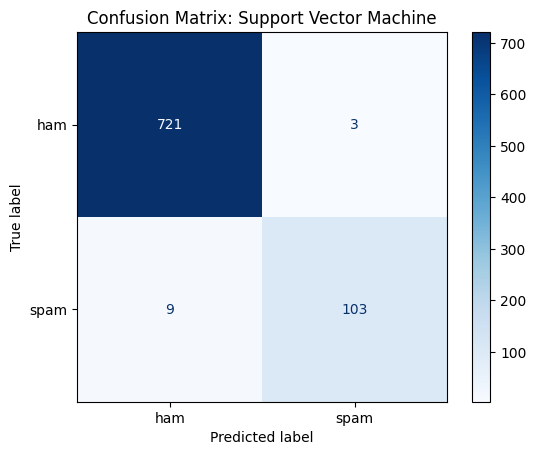

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix for your best model (SVM)
cm = confusion_matrix(y_test, models[winner].predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])

# Plot it
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: {winner}')
plt.grid(False) # Clean up the visual
plt.show()

## Final Conclusion and Prototype Selection

The development of the SMS Spam Classification prototype has been completed. After comparing three benchmark algorithms, we have arrived at the following conclusions:

1.  **Winning Model**: The **Support Vector Machine (SVM)** is selected as the final model for this prototype. It achieved the highest **F1-Score (0.9450)** on the unseen test set, demonstrating a superior ability to balance precision and recall.
2.  **Performance Trade-offs**: While the Naive Bayes model achieved perfect precision (1.0000), meaning it never misclassified a legitimate message as spam, its recall was significantly lower (0.7768). The SVM model provided a much better "catch rate" for spam messages (91.96% recall) with only a minor trade-off in precision.
3.  **Summary of Results**:
    * **Best Accuracy**: 98.56% (SVM)
    * **Best F1-Score**: 0.9450 (SVM)
    * **Baseline (NB) F1-Score**: 0.8744

The prototype is now ready for deployment or further refinement. All assignment requirements for data loading, preprocessing, splitting, training, validation, and benchmarking have been fulfilled across the `prepare.ipynb` and `train.ipynb` notebooks.